# J/ψ Peak Regression and Mass Estimation

This notebook performs a quantitative analysis of the J/ψ mass peak reconstructed from opposite-charge muon pairs.

The J/ψ-region candidates were selected in the invariant mass range 2.9–3.3 GeV in the previous notebook. Here, the mass distribution will be modeled to estimate the position and width of the peak.

Number of J/ψ-region candidates: 54
[3.1696613 3.0973544 3.1505935 3.0797036 3.0187402 3.0651793 3.1368816
 3.0805333 3.2502816 3.1034093 3.2601645 3.0713038 3.0848815 3.1230364
 3.0696266 3.0268574 3.0573537 3.0451517 3.1408145 3.1791885]
Counts: [0 0 0 0 0 1 0 1 2 2 2 4 8 6 3 6 6 5 4 0 2 0 0 0 0 0 1 1 0 0]
Bin centers: [2.9066668 2.92      2.9333334 2.9466667 2.96      2.9733334 2.9866667
 3.        3.0133333 3.0266666 3.04      3.0533333 3.0666666 3.08
 3.0933332 3.1066666 3.12      3.1333334 3.1466668 3.16      3.1733334
 3.1866667 3.2       3.2133334 3.2266667 3.24      3.2533333 3.2666667
 3.28      3.2933333]
Peak height: 6.101064685881811
Estimated J/ψ mass: 3.091977544918845 GeV
Estimated peak width (sigma): 0.04604207350297977 GeV


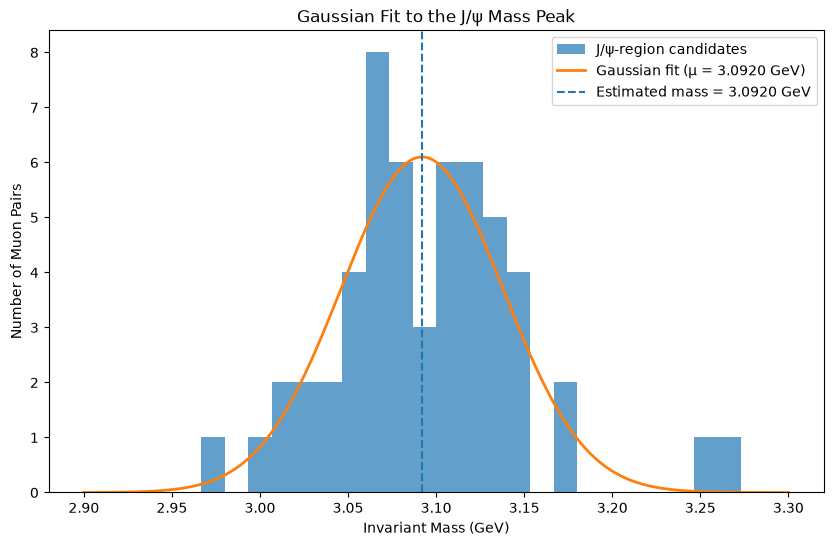

Peak height: 6.1011 ± 0.5233
Estimated J/ψ mass: 3.0920 ± 0.0046 GeV
Peak width (sigma): 0.0460 ± 0.0046 GeV
Expected J/ψ mass: 3.0970 GeV
Reconstructed mass: 3.0920 ± 0.0046 GeV
Difference: 0.0050 GeV
Percentage difference: 0.162%


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    return A*np.exp(-((x - mu)**2) / (2*sigma**2))

jpsi_candidates = np.load("../data/processed/jpsi_candidates.npy")

print("Number of J/ψ-region candidates:", len(jpsi_candidates))
print(jpsi_candidates[:20])

counts, bins_edges = np.histogram(
    jpsi_candidates,
    bins=30,
    range=(2.9, 3.3)
)

bin_centers = (
    bins_edges[:-1] + bins_edges[1:]
) / 2

print("Counts:", counts)
print("Bin centers:", bin_centers)

initial_guess = [
    8,      # A: approximate peak height
    3.1,    # mu: expected J/ψ mass
    0.05    # sigma: approximate width
]

params, covariance = curve_fit(
    gaussian,
    bin_centers,
    counts,
    p0=initial_guess
)

A_fit, mu_fit, sigma_fit = params

print("Peak height:", A_fit)
print("Estimated J/ψ mass:", mu_fit, "GeV")
print("Estimated peak width (sigma):", sigma_fit, "GeV")

x_fit = np.linspace(2.9, 3.3, 500)
y_fit = gaussian(x_fit, A_fit, mu_fit, sigma_fit)

plt.figure(figsize=(10,6))

plt.hist(
    jpsi_candidates,
    bins=30,
    range=(2.9, 3.3),
    alpha=0.7,
    label="J/ψ-region candidates"
)

plt.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label=f"Gaussian fit (μ = {mu_fit:.4f} GeV)"
)

plt.axvline(
    mu_fit,
    linestyle="--",
    label=f"Estimated mass = {mu_fit:.4f} GeV"
)

plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Number of Muon Pairs")
plt.title("Gaussian Fit to the J/ψ Mass Peak")

plt.legend()

plt.savefig(
    "../result/jpsi_gaussian_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

param_error = np.sqrt(np.diag(covariance))

A_error = param_error[0]
mu_error = param_error[1]
sigma_error = param_error[2]

print(f"Peak height: {A_fit:.4f} ± {A_error:.4f}")
print(f"Estimated J/ψ mass: {mu_fit:.4f} ± {mu_error:.4f} GeV")
print(f"Peak width (sigma): {sigma_fit:.4f} ± {sigma_error:.4f} GeV")

expected_mass = 3.097

difference = abs(mu_fit - expected_mass)
percent_error = (difference/expected_mass)*100


print(f"Expected J/ψ mass: {expected_mass:.4f} GeV")
print(f"Reconstructed mass: {mu_fit:.4f} ± {mu_error:.4f} GeV")
print(f"Difference: {difference:.4f} GeV")
print(f"Percentage difference: {percent_error:.3f}%")

## Conclusion

The invariant mass distribution of opposite-charge muon pairs was analyzed in the J/ψ mass region.

A Gaussian function was fitted to the reconstructed mass peak. The fitted peak position was:

M = 3.0920 ± 0.0046 GeV

This result is close to the expected J/ψ mass of approximately 3.097 GeV, with a percentage difference of approximately 0.162%.

The fitted width of the peak was:

σ = 0.0460 ± 0.0046 GeV

The difference between the reconstructed and expected values may be influenced by the limited sample size, background events, histogram binning, and the use of a simple Gaussian model without an explicit background component.